In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
dataset=pd.read_csv("pricing.csv")

In [52]:
print(dataset.columns)

Index(['Unnamed: 0', 'name', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'seats', 'max_power (in bph)',
       'Mileage Unit', 'Mileage', 'Engine (CC)'],
      dtype='object')


In [53]:
dataset = dataset.drop(columns=["Unnamed: 0"]) 
# dataset = dataset.drop("Unnamed: 0", axis=1) yai bhi sahi hai
print(dataset.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'seats', 'max_power (in bph)', 'Mileage Unit',
       'Mileage', 'Engine (CC)'],
      dtype='object')


In [56]:
x=dataset.drop("selling_price",axis=1)
y=dataset["selling_price"]
print(x)
print(y)

         name  year  km_driven    fuel seller_type transmission         owner  \
0      Maruti  2014     145500  Diesel  Individual       Manual   First Owner   
1     Hyundai  2010     127000  Diesel  Individual       Manual   First Owner   
2     Hyundai  2017      45000  Petrol  Individual       Manual   First Owner   
3      Toyota  2011      90000  Diesel  Individual       Manual   First Owner   
4        Ford  2013     169000  Diesel  Individual       Manual   First Owner   
...       ...   ...        ...     ...         ...          ...           ...   
2090   Maruti  2017      12000  Petrol  Individual       Manual   First Owner   
2091   Toyota  2014      50000  Diesel  Individual       Manual   First Owner   
2092   Maruti  2011      73000  Petrol  Individual       Manual   First Owner   
2093   Maruti  2017      80000  Petrol  Individual       Manual   First Owner   
2094  Hyundai  2014      80000  Diesel  Individual       Manual  Second Owner   

      seats  max_power (in 

In [57]:
feature_names = x.columns

In [58]:
print(type(x))
pd.DataFrame(x).nunique()#unique data type bata rha sab col ka

<class 'pandas.core.frame.DataFrame'>


name                   10
year                   20
km_driven             372
fuel                    4
seller_type             3
transmission            2
owner                   5
seats                   4
max_power (in bph)     77
Mileage Unit            2
Mileage                86
Engine (CC)            27
dtype: int64

In [59]:
print(x.shape)
print(x.columns)

(2095, 12)
Index(['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner', 'seats', 'max_power (in bph)', 'Mileage Unit', 'Mileage',
       'Engine (CC)'],
      dtype='object')


In [60]:
print(x.iloc[:,0].values)

['Maruti' 'Hyundai' 'Hyundai' ... 'Maruti' 'Maruti' 'Hyundai']


In [61]:
print(dataset.iloc[:, 4].values)
print(dataset.dtypes)

['Diesel' 'Diesel' 'Petrol' ... 'Petrol' 'Petrol' 'Diesel']
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
seats                   int64
max_power (in bph)    float64
Mileage Unit           object
Mileage               float64
Engine (CC)             int64
dtype: object


In [62]:
print(type(x))
print(x.dtypes)

<class 'pandas.core.frame.DataFrame'>
name                   object
year                    int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
seats                   int64
max_power (in bph)    float64
Mileage Unit           object
Mileage               float64
Engine (CC)             int64
dtype: object


In [63]:
print(type(x))

<class 'pandas.core.frame.DataFrame'>


In [64]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

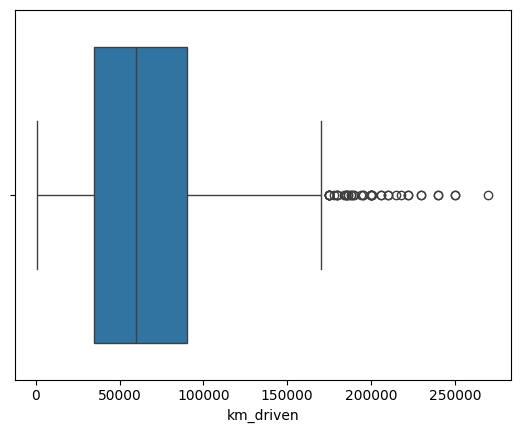

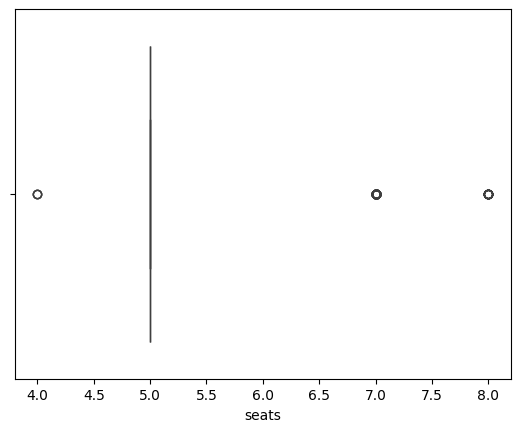

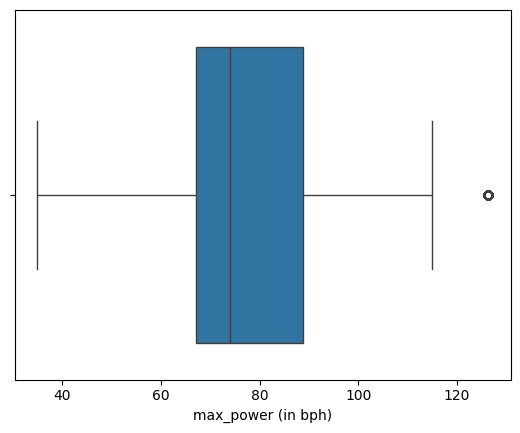

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
# outlier detect
sns.boxplot(x=dataset["km_driven"])
plt.show()
sns.boxplot(x=dataset["seats"])
plt.show()
sns.boxplot(x=dataset["max_power (in bph)"])#in sab mai outlier  hai
plt.show()


In [66]:
#Python ko nahi pata ye kya karta hai (custom transformer)
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierHandler(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):#Jo bhi attribute fit() me create hota hai, uske end me _ lagate hain
        self.Q1_ = np.percentile(x, 25, axis=0)
        self.Q3_ = np.percentile(x, 75, axis=0)
        self.IQR_ = self.Q3_ - self.Q1_
        return self
    
    def transform(self, x):
        lower = self.Q1_ - 1.5 * self.IQR_
        upper = self.Q3_ + 1.5 * self.IQR_
        
        x= np.clip(x, lower, upper)
        return x

    def get_feature_names_out(self, input_features=None):
        return input_features

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

num_cols = x.select_dtypes(include=np.number).columns
cat_cols = x.select_dtypes(exclude=np.number).columns
ct = ColumnTransformer([
    ('num',Pipeline([
        ('impute',SimpleImputer(strategy='mean')),
        ('outliers', OutlierHandler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder())
    ]), cat_cols)
])

x_train_ct= ct.fit_transform(x_train)
x_test_ct = ct.transform(x_test)
feature_names = ct.get_feature_names_out()#yai name leta hai col ka dono type kai data sai kyuki array bante hi sirf number reh jate hai

In [68]:
print(id(ct))

1808459345360


In [69]:
print(dataset['owner'].unique())
print(dataset['Mileage Unit'].nunique())
print(dataset['seller_type'].nunique())

['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
2
3


In [70]:
print(type(x_ct))

<class 'numpy.ndarray'>


In [71]:
print(x_ct.shape)
pd.DataFrame(x).nunique()#temporarily DataFrame me convert ho raha hai Fir .nunique() apply ho raha hai

(1676, 32)


name                   10
year                   20
km_driven             372
fuel                    4
seller_type             3
transmission            2
owner                   5
seats                   4
max_power (in bph)     77
Mileage Unit            2
Mileage                86
Engine (CC)            27
dtype: int64

In [72]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0)
x_train_vt = vt.fit_transform(x_train_ct)
x_test_vt = vt.transform(x_test_ct)
feature_names = feature_names[vt.get_support()]#VarianceThreshold ke baad names change hote hain

In [73]:
from sklearn.feature_selection import SelectKBest, f_regression
selector=SelectKBest(score_func=f_regression,k=10)
x_train_new=selector.fit_transform(x_train_vt,y_train)
x_test_new = selector.transform(x_test_vt)

selected_features = feature_names[selector.get_support()]

print("Selected Features:\n", selected_features)

Selected Features:
 ['num__year' 'num__km_driven' 'num__max_power (in bph)' 'num__Mileage'
 'num__Engine (CC)' 'cat__name_Maruti' 'cat__fuel_Diesel'
 'cat__fuel_Petrol' 'cat__owner_First Owner' 'cat__owner_Second Owner']


In [75]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
ran_regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
ran_regressor.fit(x_train_new, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [48]:
type(y_test)#kyuki koi column jab drop karke lo ak single to vo series basn jata hai

pandas.core.series.Series

In [76]:
y_pred_ran = ran_regressor.predict(x_test_new)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_ran.reshape(len(y_pred_ran),1), y_test.values.reshape(len(y_test),1)),1)[:10])

[[870856.67 800000.  ]
 [407500.   300000.  ]
 [162560.   131000.  ]
 [244495.   250000.  ]
 [430568.33 515000.  ]
 [155150.   180000.  ]
 [571790.   500000.  ]
 [342449.99 350000.  ]
 [196770.   200000.  ]
 [429034.99 400000.  ]]


In [77]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_ran)

0.8862984313301997

In [78]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor
dec_regressor = DecisionTreeRegressor(random_state = 0)
dec_regressor.fit(x_train_new, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [79]:
y_pred_dec = dec_regressor.predict(x_test_new)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_dec.reshape(len(y_pred_dec),1), y_test.values.reshape(len(y_test),1)),1)[:10])

[[750000. 800000.]
 [350000. 300000.]
 [165000. 131000.]
 [250000. 250000.]
 [420000. 515000.]
 [129000. 180000.]
 [620000. 500000.]
 [250000. 350000.]
 [189000. 200000.]
 [440000. 400000.]]


In [80]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_dec)

0.804555903050655

In [81]:
#xgboost regression
from xgboost import XGBRegressor
xg_regressor= XGBRegressor()
xg_regressor.fit(x_train_new,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [82]:
y_pred_xg = xg_regressor.predict(x_test_new)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_xg.reshape(len(y_pred_xg),1), y_test.values.reshape(len(y_test),1)),1)[:10])

[[875125.31 800000.  ]
 [422178.78 300000.  ]
 [166376.47 131000.  ]
 [245191.61 250000.  ]
 [415077.03 515000.  ]
 [161027.39 180000.  ]
 [580529.31 500000.  ]
 [340726.   350000.  ]
 [185227.12 200000.  ]
 [442356.59 400000.  ]]


In [83]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_xg)

0.8820016980171204

In [84]:
#multiple linear regression
from sklearn.linear_model import LinearRegression
li_regressor=LinearRegression()
li_regressor.fit(x_train_new,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
y_pred_li=li_regressor.predict(x_test_new)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_li.reshape(len(y_pred_li),1),y_test.values.reshape(len(y_test),1)),1)[:10])

[[684950.44 800000.  ]
 [512368.03 300000.  ]
 [140140.06 131000.  ]
 [269287.64 250000.  ]
 [503020.15 515000.  ]
 [ 79536.33 180000.  ]
 [656975.68 500000.  ]
 [340098.46 350000.  ]
 [232899.81 200000.  ]
 [554064.7  400000.  ]]


In [86]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_li)

0.7392037948027648

In [87]:
#polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_reg = PolynomialFeatures(degree = 2)
x_poly = poly_reg.fit_transform(x_train_new)
li_regressor2 = LinearRegression()
li_regressor2.fit(x_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
y_pred_poly = li_regressor2.predict(poly_reg.transform(x_test_new))
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_poly.reshape(len(y_pred_poly),1), y_test.values.reshape(len(y_test),1)),1)[:10])

[[824823.76 800000.  ]
 [495964.13 300000.  ]
 [183201.38 131000.  ]
 [263548.75 250000.  ]
 [461998.31 515000.  ]
 [184121.35 180000.  ]
 [652700.23 500000.  ]
 [357049.31 350000.  ]
 [297058.05 200000.  ]
 [438313.57 400000.  ]]


In [89]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_poly)

0.8356429796592222

In [90]:
from sklearn.preprocessing import StandardScaler#yai 2d array leta hai
sc_x=StandardScaler()
sc_y=StandardScaler()
x_train_new = sc_x.fit_transform(x_train_new)
x_test_new = sc_x.transform(x_test_new)#Test data se kuch "seekhna" nahi hai Sirf training wale scale pe convert karna hai
y_train = sc_y.fit_transform(y_train.values.reshape(-1,1))

In [91]:
from sklearn.svm import SVR
svr_regressor = SVR(kernel = 'rbf')
svr_regressor.fit(x_train_new, y_train)

C:\Users\mehak\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [92]:
y_pred_svr = sc_y.inverse_transform(svr_regressor.predict(x_test_new).reshape(-1,1))
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_svr.reshape(len(y_pred_svr),1), y_test.values.reshape(len(y_test),1)),1)[:10])

[[880880.28 800000.  ]
 [464627.05 300000.  ]
 [177091.23 131000.  ]
 [249262.66 250000.  ]
 [459660.04 515000.  ]
 [180020.97 180000.  ]
 [609517.67 500000.  ]
 [323448.21 350000.  ]
 [284456.81 200000.  ]
 [430869.43 400000.  ]]


In [93]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_svr)

0.8297757348952242

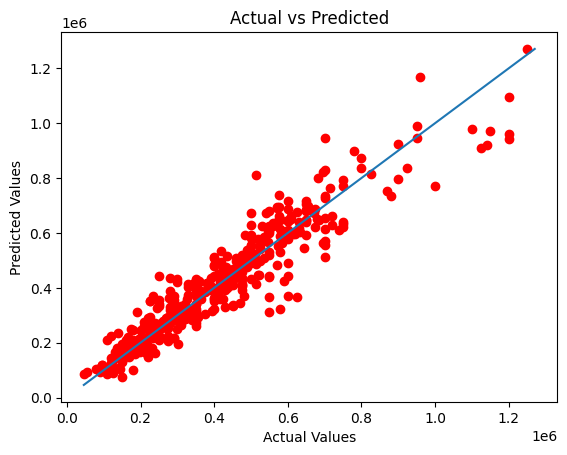

In [94]:
plt.figure()
plt.scatter(y_test, y_pred_xg, color="red")
min_val = min(min(y_test), min(y_pred_xg))#y_test ka smallest value y_pred ka smallest value Dono mein se jo sabse chhota hai → min_val
max_val = max(max(y_test), max(y_pred_xg))

plt.plot([min_val, max_val], [min_val, max_val])#Ye exactly ek straight line banata hai:
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [95]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(ct)

In [96]:
print(ct)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute', SimpleImputer()),
                                                 ('outliers',
                                                  OutlierHandler())]),
                                 Index(['year', 'km_driven', 'seats', 'max_power (in bph)', 'Mileage',
       'Engine (CC)'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OneHotEncoder())]),
                                 Index(['name', 'fuel', 'seller_type', 'transmission', 'owner', 'Mileage Unit'], dtype='object'))])


In [97]:
print(id(ct))

1808459345360


In [98]:
new_data = pd.DataFrame([{
    'name': 'Maruti',
    'year': 2014,
    'km_driven': 145500,
    'fuel': 'Diesel',
    'seller_type': 'Dealer',
    'transmission': 'Manual',
    'owner': 'First Owner',
    'seats': 5,
    'max_power (in bph)': 74.0,
    'Mileage Unit': 'kmpl',
    'Mileage': 23.4,
    'Engine (CC)': 1248
}])

# 🔹 Step 2: pipeline apply
new_ct = ct.transform(new_data)
new_vt = vt.transform(new_ct)
selected_data = selector.transform(new_vt)

# 🔹 Step 3: prediction
prediction = xg_regressor.predict(selected_data)

print("Predicted Car Price:", prediction[0])

Predicted Car Price: 458041.9
